In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn as nn

In [2]:
torch.manual_seed(10)

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device={device}")

using device=cuda


In [4]:
df=pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


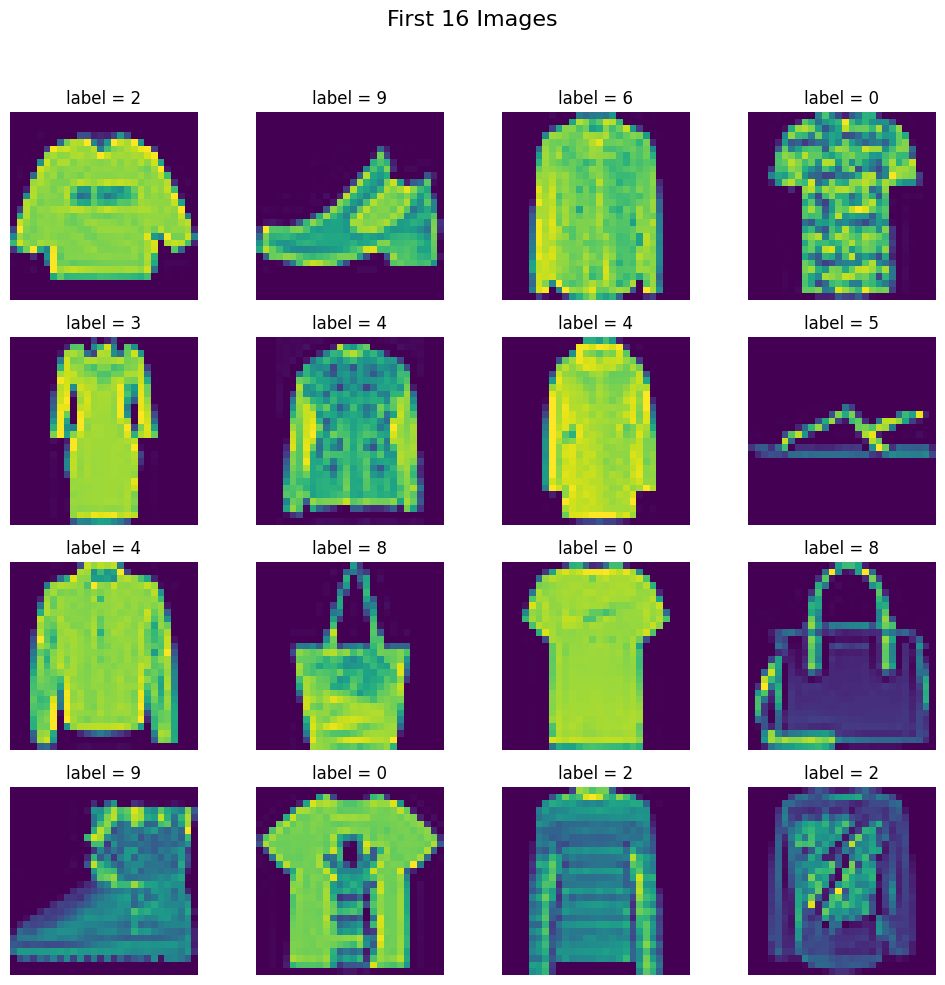

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('First 16 Images', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img) # Added cmap for better image contrast
    ax.axis('off')
    # Fixed string formatting for the title
    ax.set_title(f'label = {df.iloc[i,0]}')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjusted the top boundary to prevent title overlap
plt.show()


In [6]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [8]:
x_train=x_train/255.0
x_test=x_test/255.0

In [9]:
class Customdataset(Dataset):

  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [10]:
train_dataset=Customdataset(x_train,y_train)
test_dataset=Customdataset(x_test,y_test)

In [11]:
test_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [12]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True , pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False , pin_memory=True)

In [13]:
class MyNN(nn.Module):

  def __init__(self, num_feactures):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_feactures,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),

    )


  def forward(self,x):
    return self.model(x

    )

In [14]:
epochs=100
learning_rate=0.001

In [15]:
model=MyNN(x_train.shape[1])
model=model.to(device)


criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(model.parameters(),lr=learning_rate)





In [16]:

for epoch in range(epochs):

    total_loss = 0.0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 0.5500
Epoch [2/100], Loss: 0.3960
Epoch [3/100], Loss: 0.3577
Epoch [4/100], Loss: 0.3340
Epoch [5/100], Loss: 0.3129
Epoch [6/100], Loss: 0.2978
Epoch [7/100], Loss: 0.2816
Epoch [8/100], Loss: 0.2711
Epoch [9/100], Loss: 0.2603
Epoch [10/100], Loss: 0.2472
Epoch [11/100], Loss: 0.2400
Epoch [12/100], Loss: 0.2316
Epoch [13/100], Loss: 0.2240
Epoch [14/100], Loss: 0.2166
Epoch [15/100], Loss: 0.2092
Epoch [16/100], Loss: 0.2023
Epoch [17/100], Loss: 0.1957
Epoch [18/100], Loss: 0.1940
Epoch [19/100], Loss: 0.1857
Epoch [20/100], Loss: 0.1813
Epoch [21/100], Loss: 0.1756
Epoch [22/100], Loss: 0.1727
Epoch [23/100], Loss: 0.1649
Epoch [24/100], Loss: 0.1637
Epoch [25/100], Loss: 0.1585
Epoch [26/100], Loss: 0.1536
Epoch [27/100], Loss: 0.1509
Epoch [28/100], Loss: 0.1435
Epoch [29/100], Loss: 0.1427
Epoch [30/100], Loss: 0.1390
Epoch [31/100], Loss: 0.1366
Epoch [32/100], Loss: 0.1352
Epoch [33/100], Loss: 0.1274
Epoch [34/100], Loss: 0.1263
Epoch [35/100], Loss: 0

In [17]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [18]:
total=0
correct=0



with torch.no_grad():
  for batch_features, batch_labels in test_loader:

    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)
    outputs=model(batch_features)
    _,predicted=torch.max(outputs.data,1)
    total+=batch_labels.size(0)
    correct+=(predicted==batch_labels).sum().item()

print(correct/total)

0.8840833333333333
